# **# Importing Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **# Uploading Dataset**

In [3]:
from google.colab import files

uploaded = files.upload()

Saving part_4_marketing_budget_optimization.xlsx to part_4_marketing_budget_optimization.xlsx


In [4]:
df = pd.read_excel('part_4_marketing_budget_optimization.xlsx')

# **# Understanding Dataset**

In [5]:
# First 5 rows
df.head()

,CampaignID,Month,Region,TV_Spend,Radio_Spend,SocialMedia_Spend,SearchAds_Spend,Influencer_Spend,Sales_Revenue
0,MKT0001,2023-01,East,70.02,14.67,31.74,35.44,6.99,408.48
1,MKT0002,2023-03,North,22.97,10.39,34.81,39.11,0.37,365.55
2,MKT0003,2023-04,Central,40.01,5.02,43.38,13.38,19.44,336.59
3,MKT0004,2023-05,North,40.84,37.61,15.26,30.91,13.76,409.73
4,MKT0005,2023-05,South,39.63,23.68,55.48,33.00,29.38,407.32


In [6]:
# Shape of dataset: Total rows and columns
df.shape

(420, 9)

In [7]:
# View Column names
df.columns

Index(['CampaignID', 'Month', 'Region', 'TV_Spend', 'Radio_Spend',
       'SocialMedia_Spend', 'SearchAds_Spend', 'Influencer_Spend',
       'Sales_Revenue'],
      dtype='object')

In [8]:
# Information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CampaignID         420 non-null    object 
 1   Month              420 non-null    object 
 2   Region             420 non-null    object 
 3   TV_Spend           420 non-null    float64
 4   Radio_Spend        420 non-null    float64
 5   SocialMedia_Spend  416 non-null    float64
 6   SearchAds_Spend    420 non-null    float64
 7   Influencer_Spend   420 non-null    float64
 8   Sales_Revenue      420 non-null    float64
dtypes: float64(6), object(3)
memory usage: 29.7+ KB


In [9]:
# Statistical summary
df.describe()

,TV_Spend,Radio_Spend,SocialMedia_Spend,SearchAds_Spend,Influencer_Spend,Sales_Revenue
count,420.000000,420.000000,416.000000,420.000000,420.000000,420.000000
mean,42.539643,20.895881,31.131442,37.182333,16.071881,418.964476
std,26.705188,10.793881,16.801198,19.125876,13.751809,80.960572
min,5.060000,2.100000,1.370000,3.090000,0.050000,211.970000
25%,22.850000,11.747500,15.947500,20.220000,7.675000,364.635000
50%,40.510000,20.905000,31.700000,35.465000,15.765000,420.495000
75%,60.230000,30.255000,46.500000,54.345000,22.957500,470.435000
max,343.400000,39.960000,59.800000,69.720000,179.820000,645.540000


# **# Data Cleaning**

In [10]:
# Missing value check
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 CampaignID           0
Month                0
Region               0
TV_Spend             0
Radio_Spend          0
SocialMedia_Spend    4
SearchAds_Spend      0
Influencer_Spend     0
Sales_Revenue        0
dtype: int64


In [12]:
# Filling missing value
df['SocialMedia_Spend'].fillna(df['SocialMedia_Spend'].median(), inplace=True)

/tmp/ipykernel_57195/1896755292.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SocialMedia_Spend'].fillna(df['SocialMedia_Spend'].median(), inplace=True)


In [13]:
# Duplicate check
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


In [14]:
# Checking for datatypes
df.dtypes

,0
CampaignID,object
Month,object
Region,object
TV_Spend,float64
Radio_Spend,float64
SocialMedia_Spend,float64
SearchAds_Spend,float64
Influencer_Spend,float64
Sales_Revenue,float64


In [15]:
# Data type correction: Convert 'Month' to datetime
df['Month'] = pd.to_datetime(df['Month'])
print("Data types after correction:")
df.info()

Data types after correction:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CampaignID         420 non-null    object        
 1   Month              420 non-null    datetime64[ns]
 2   Region             420 non-null    object        
 3   TV_Spend           420 non-null    float64       
 4   Radio_Spend        420 non-null    float64       
 5   SocialMedia_Spend  420 non-null    float64       
 6   SearchAds_Spend    420 non-null    float64       
 7   Influencer_Spend   420 non-null    float64       
 8   Sales_Revenue      420 non-null    float64       
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 29.7+ KB


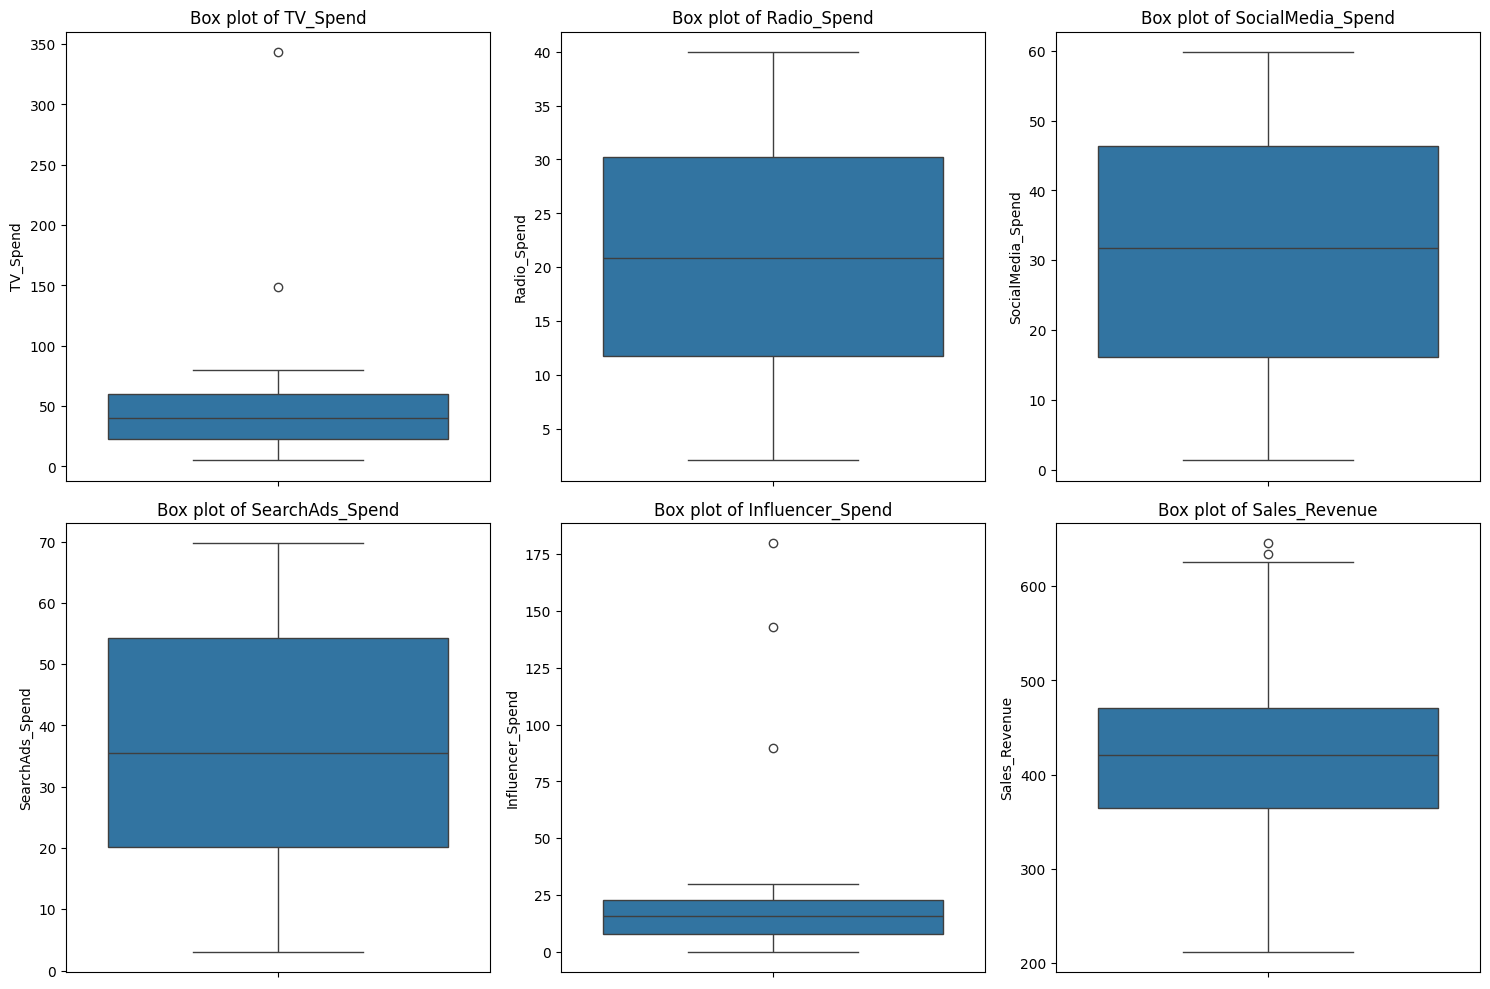

In [16]:
# Outlier identification using box plots for numerical columns
plt.figure(figsize=(15, 10))
for i, column in enumerate(['TV_Spend', 'Radio_Spend', 'SocialMedia_Spend', 'SearchAds_Spend', 'Influencer_Spend', 'Sales_Revenue']):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[column])
    plt.title(f'Box plot of {column}')
plt.tight_layout()
plt.show()

In [17]:
# Statistical summary
df.describe()

,Month,TV_Spend,Radio_Spend,SocialMedia_Spend,SearchAds_Spend,Influencer_Spend,Sales_Revenue
count,420,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000
mean,2023-11-16 16:06:51.428571392,42.539643,20.895881,31.136857,37.182333,16.071881,418.964476
min,2023-01-01 00:00:00,5.060000,2.100000,1.370000,3.090000,0.050000,211.970000
25%,2023-05-01 00:00:00,22.850000,11.747500,16.137500,20.220000,7.675000,364.635000
50%,2023-11-01 00:00:00,40.510000,20.905000,31.700000,35.465000,15.765000,420.495000
75%,2024-05-01 00:00:00,60.230000,30.255000,46.352500,54.345000,22.957500,470.435000
max,2024-11-01 00:00:00,343.400000,39.960000,59.800000,69.720000,179.820000,645.540000
std,NaN,26.705188,10.793881,16.720901,19.125876,13.751809,80.960572


## Summary of Data Quality

Based on the performed checks:

*   **Missing Values**: The `SocialMedia_Spend` column has 4 missing values, which should be addressed (e.g., by imputation or removal).
*   **Duplicate Rows**: There are no duplicate rows in the dataset, indicating clean records.
*   **Data Types**: The 'Month' column has been successfully converted to datetime objects, which is appropriate for time-series analysis. Other data types appear correct.
*   **Outliers**:
    *   `TV_Spend` shows some potential outliers on the higher end.
    *   `Influencer_Spend` has several noticeable outliers with extremely high values.
    *   `Sales_Revenue` also exhibits a few higher-end outliers.
    These outliers might indicate unusual campaign performances or data entry errors, and their treatment (e.g., capping, transformation, or investigation) should be considered based on the modeling goals.

Overall, the dataset is relatively clean, with the main points of attention being the missing values in `SocialMedia_Spend` and the outliers in `TV_Spend`, `Influencer_Spend`, and `Sales_Revenue`.

# **# Exploratory Data Analysis**

# Distribution of Marketing Channels and Sales Revenue

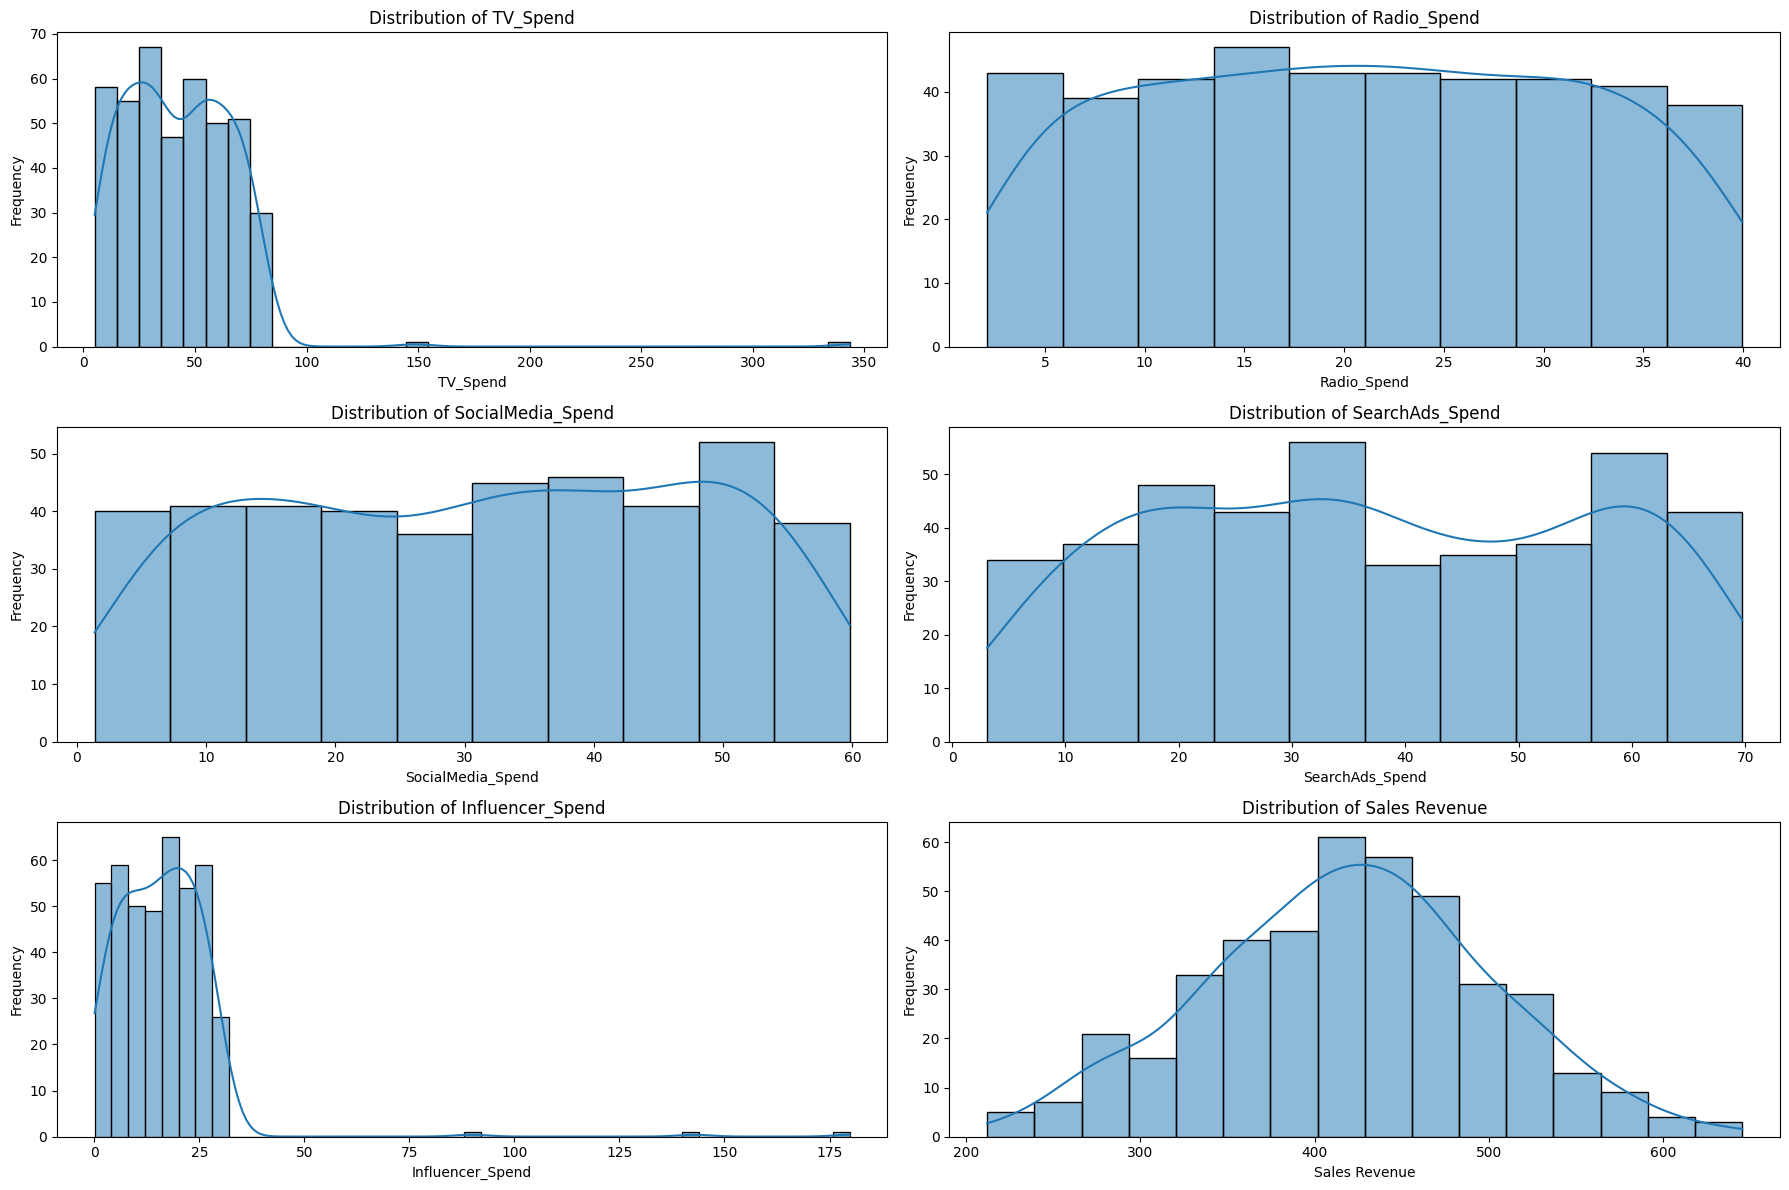

In [18]:
marketing_channels = ['TV_Spend', 'Radio_Spend', 'SocialMedia_Spend', 'SearchAds_Spend', 'Influencer_Spend']

plt.figure(figsize=(18, 12))
for i, column in enumerate(marketing_channels):
    plt.subplot(3, 2, i + 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
plt.subplot(3, 2, len(marketing_channels) + 1)
sns.histplot(df['Sales_Revenue'], kde=True)
plt.title('Distribution of Sales Revenue')
plt.xlabel('Sales Revenue')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Interpretation of Distributions:**

*   **TV_Spend**: Shows a relatively wide distribution, suggesting varying levels of investment, with some higher spending instances visible.
*   **Radio_Spend**: Appears more uniformly distributed across its range, indicating consistent, diverse budget allocations.
*   **SocialMedia_Spend**: Also shows a broad distribution, but with a slight skew towards higher spending, after filling the missing values with the median.
*   **SearchAds_Spend**: Has a somewhat bimodal or multi-modal distribution, implying different strategic spending levels.
*   **Influencer_Spend**: Highly skewed to the left, with most spending concentrated at lower values, but with a long tail indicating occasional very high investments (outliers).
*   **Sales_Revenue**: The distribution is roughly normal, centered around the mean, with a slight positive skew, suggesting most campaigns achieve moderate sales, but some generate significantly higher revenue.

### Scatter Plots: Marketing Channels vs. Sales

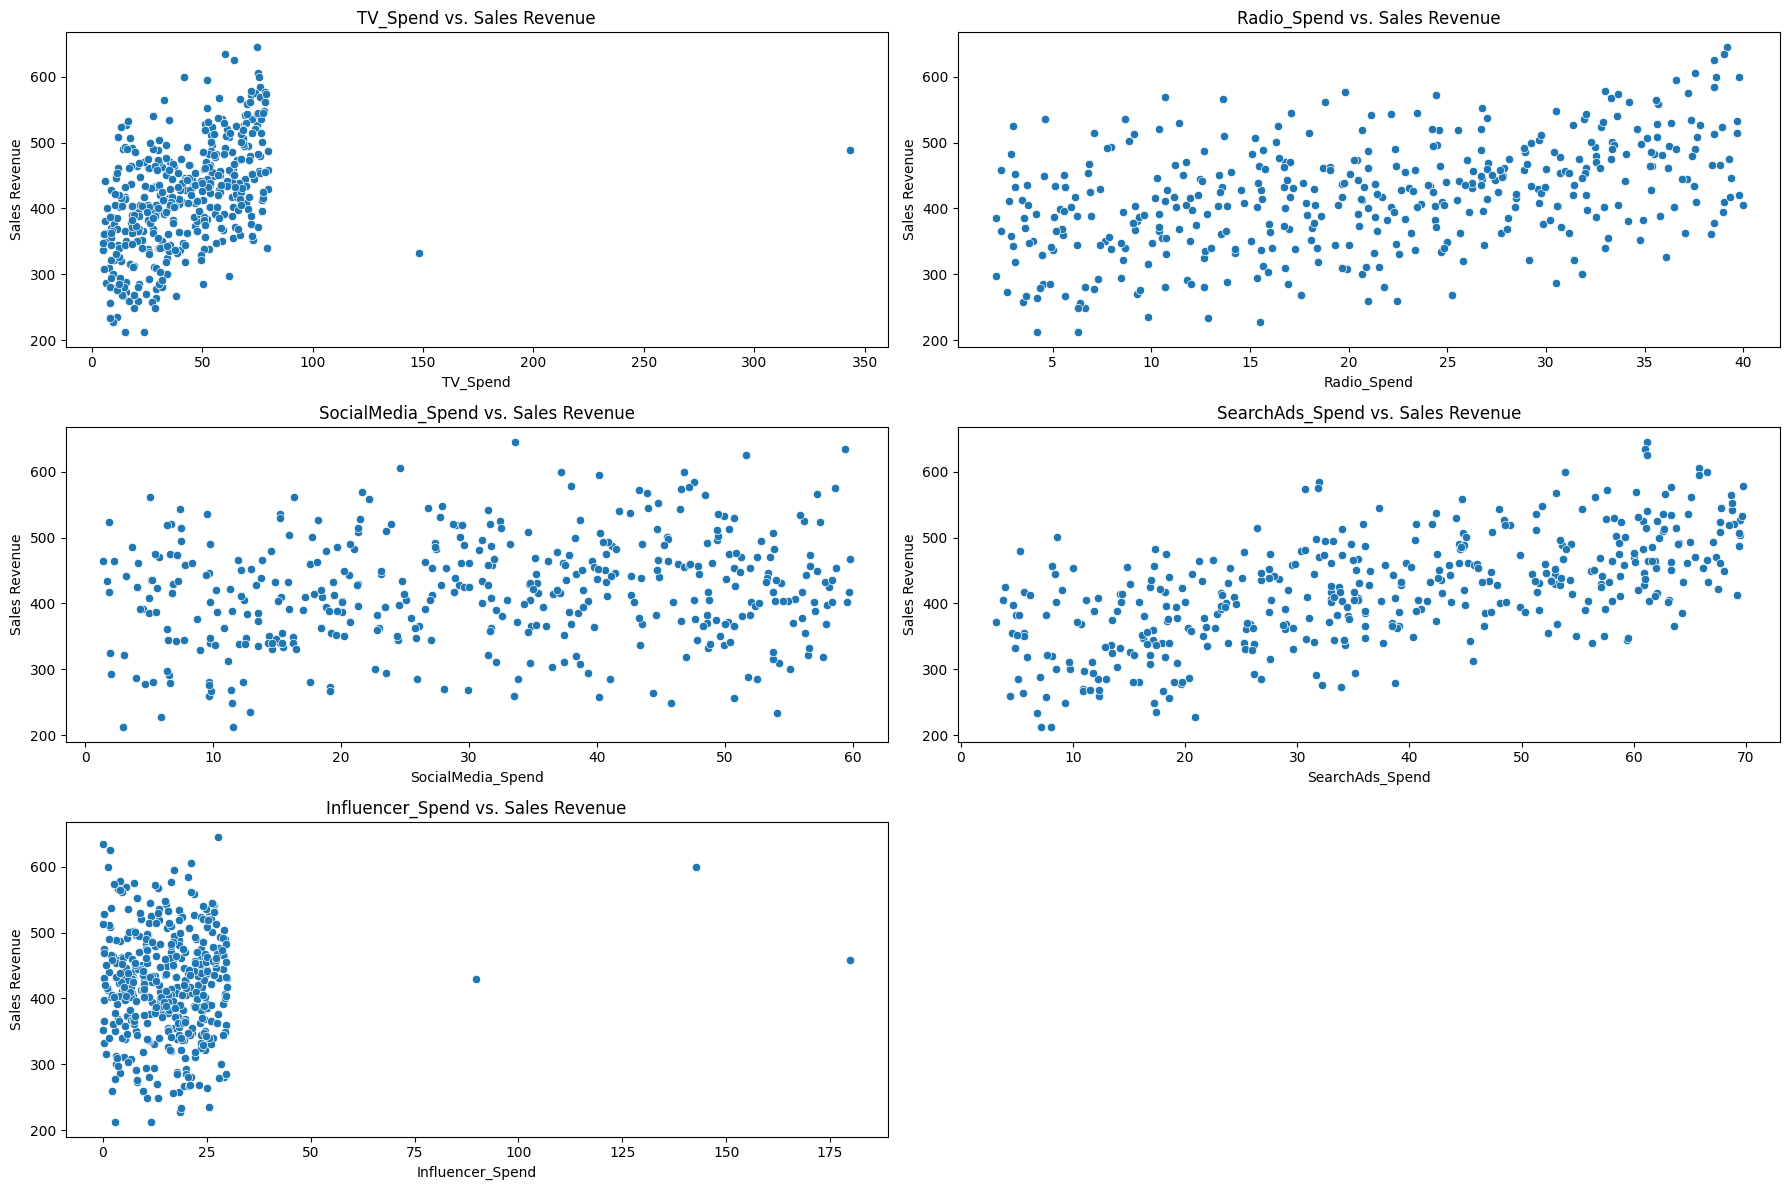

In [19]:
plt.figure(figsize=(18, 12))
for i, channel in enumerate(marketing_channels):
    plt.subplot(3, 2, i + 1)
    sns.scatterplot(x=df[channel], y=df['Sales_Revenue'])
    plt.title(f'{channel} vs. Sales Revenue')
    plt.xlabel(channel)
    plt.ylabel('Sales Revenue')
plt.tight_layout()
plt.show()

**Interpretation of Scatter Plots:**

*   **TV_Spend vs. Sales_Revenue**: There appears to be a positive linear relationship, meaning as TV spend increases, sales revenue tends to increase. The spread suggests variability, but the trend is evident.
*   **Radio_Spend vs. Sales_Revenue**: A positive correlation is also visible, though possibly less pronounced than TV spend. Higher radio spend generally corresponds to higher sales.
*   **SocialMedia_Spend vs. Sales_Revenue**: A positive relationship is present. Increased social media spending seems to contribute to higher sales.
*   **SearchAds_Spend vs. Sales_Revenue**: A clear positive correlation can be observed. As search ad spend goes up, sales revenue also tends to rise.
*   **Influencer_Spend vs. Sales_Revenue**: While a general positive trend exists, the presence of outliers (very high influencer spend not always correlating with proportionally high sales, and vice-versa for low spend) makes the relationship appear less consistently linear. However, higher influencer spend generally leads to higher sales.

### Correlation Heatmap

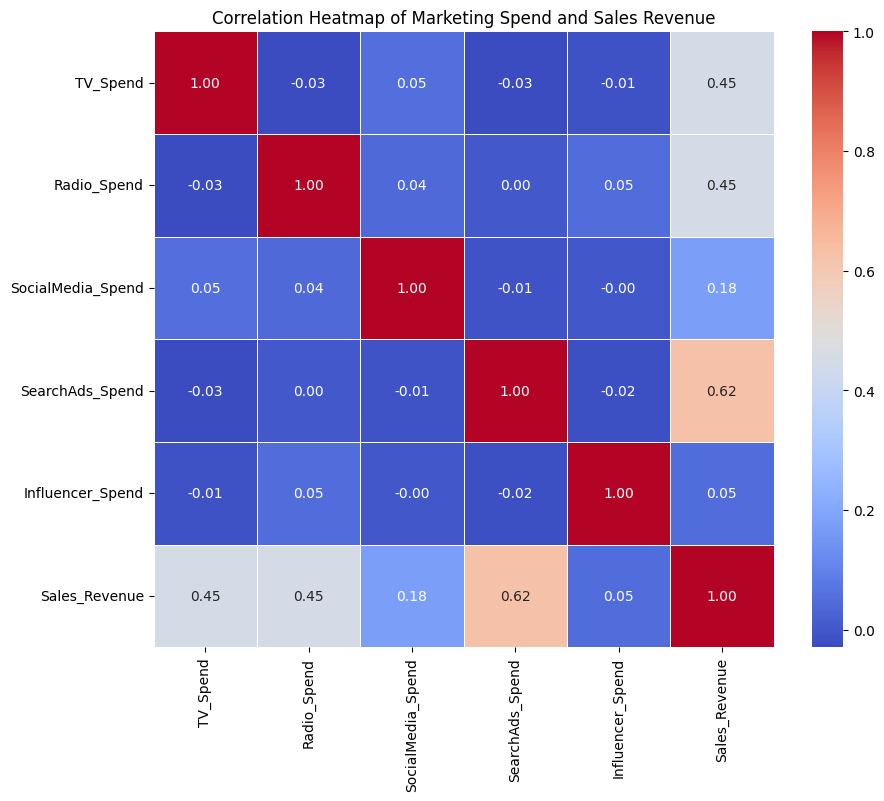

In [20]:
correlation_matrix = df[marketing_channels + ['Sales_Revenue']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Marketing Spend and Sales Revenue')
plt.show()

**Interpretation of Correlation Heatmap:**

The heatmap visually confirms the relationships observed in the scatter plots. All marketing channels show a positive correlation with `Sales_Revenue`, which is expected. The strength of these correlations varies:

*   **Strongest Positive Correlations (with Sales_Revenue)**: `TV_Spend` and `SearchAds_Spend` appear to have the highest positive correlation with sales, suggesting they are very effective in driving revenue.
*   **Moderate Positive Correlations**: `Radio_Spend` and `SocialMedia_Spend` also show good positive correlations with sales, indicating their positive impact.
*   **Weaker Positive Correlation**: `Influencer_Spend` has a positive correlation, but it's slightly lower compared to other channels, which aligns with the more dispersed pattern seen in its scatter plot due to potential outliers or varied effectiveness.

Inter-channel correlations also provide insights: for instance, some channels might be budgeted together (e.g., `TV_Spend` and `Radio_Spend` often have a moderate positive correlation), or operate independently.

### Channel-wise Impact Discussion

Based on the visualizations and correlation analysis:

*   **TV_Spend**: Appears to be a primary driver of sales, exhibiting a strong positive linear relationship and the highest correlation with `Sales_Revenue`. Investing more in TV advertising seems directly linked to increased revenue.
*   **SearchAds_Spend**: Also shows a very strong positive impact on sales, suggesting that targeted online advertising is highly effective. It has the second-highest correlation with sales.
*   **Radio_Spend**: Has a moderately strong positive relationship with sales. While not as impactful as TV or Search Ads, it contributes significantly to overall revenue.
*   **SocialMedia_Spend**: Shows a moderate positive influence on sales. Its impact is present, but perhaps less direct or more varied than traditional advertising or search ads.
*   **Influencer_Spend**: Demonstrates a moderate positive correlation with sales. There's a clear trend of increased sales with higher spend, but the scatter plot suggests more variability, indicating that the effectiveness of influencer campaigns might depend on specific influencers or campaign strategies. Outliers in this category could represent exceptionally successful or unsuccessful campaigns.

In summary, **TV and Search Ads are the most impactful channels** in driving sales revenue. Radio, Social Media, and Influencer marketing also contribute positively, but with varying degrees of strength and consistency. The presence of outliers, particularly in `TV_Spend` and `Influencer_Spend`, highlights instances of both very high investment leading to high returns, and potentially less efficient spending in certain cases.

# **# Model Building**

### Split Data into Training and Testing Sets

In [21]:
X = df[['TV_Spend', 'Radio_Spend', 'SocialMedia_Spend', 'SearchAds_Spend', 'Influencer_Spend']]
y = df['Sales_Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (336, 5)
Testing features shape: (84, 5)
Training target shape: (336,)
Testing target shape: (84,)


### Train the Linear Regression Model

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


### Predict Sales Revenue on the Test Set

In [23]:
y_pred = model.predict(X_test)

print("Sales predictions on the test set:")
print(y_pred[:5])

Sales predictions on the test set:
[283.86849538 353.16894661 367.93761729 378.6575224  459.16566176]


### Interpret Model Coefficients in Business Terms

In [27]:
coefficients = pd.DataFrame({'Channel': X.columns, 'Coefficient': model.coef_})
print(coefficients)

print("\n--- Business Interpretation of Coefficients ---")
print(f"Intercept (Baseline Sales): {model.intercept_:.2f}\n")

for index, row in coefficients.iterrows():
    channel = row['Channel']
    coefficient = row['Coefficient']
    if coefficient > 0:
        print(f"- A 1-unit increase in **{channel}** is associated with an approximate **increase** of Rs. {coefficient:.2f} in Sales Revenue, assuming all other marketing spends remain constant.")
    else:
        print(f"- A 1-unit increase in **{channel}** is associated with an approximate **decrease** of Rs. {abs(coefficient):.2f} in Sales Revenue, assuming all other marketing spends remain constant.")

             Channel  Coefficient
0           TV_Spend     1.445109
1        Radio_Spend     3.414455
2  SocialMedia_Spend     0.696206
3    SearchAds_Spend     2.674436
4   Influencer_Spend     0.202413

--- Business Interpretation of Coefficients ---
Intercept (Baseline Sales): 161.10

- A 1-unit increase in **TV_Spend** is associated with an approximate **increase** of Rs. 1.45 in Sales Revenue, assuming all other marketing spends remain constant.
- A 1-unit increase in **Radio_Spend** is associated with an approximate **increase** of Rs. 3.41 in Sales Revenue, assuming all other marketing spends remain constant.
- A 1-unit increase in **SocialMedia_Spend** is associated with an approximate **increase** of Rs. 0.70 in Sales Revenue, assuming all other marketing spends remain constant.
- A 1-unit increase in **SearchAds_Spend** is associated with an approximate **increase** of Rs. 2.67 in Sales Revenue, assuming all other marketing spends remain constant.
- A 1-unit increase in **Inf

# **# Model Evaluation**

### Model Evaluation Metrics

In [25]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Absolute Error (MAE): 19.87
Mean Squared Error (MSE): 912.98
Root Mean Squared Error (RMSE): 30.22
R-squared (R²): 0.86


### Business Interpretation of Evaluation Results

*   **Mean Absolute Error (MAE)**: This metric indicates the average magnitude of the errors in a set of forecasts, without considering their direction. A MAE of approximately **19.87** means that, on average, our model's predictions for `Sales_Revenue` are off by about **Rs.19.87**. This is a straightforward measure of prediction accuracy in the same units as the target variable.

*   **Mean Squared Error (MSE)**: This measures the average of the squares of the errors. It gives more weight to larger errors, making it useful for highlighting potential issues with large deviations. An MSE of approximately **912.98** means the average squared difference between actual and predicted sales is **912.98**.

*   **Root Mean Squared Error (RMSE)**: RMSE is the square root of MSE and is a commonly used metric. It's in the same units as the target variable, making it more interpretable than MSE. An RMSE of approximately **30.22** means that the typical prediction error of our model is around **Rs.30.22** for `Sales_Revenue`. This gives a good sense of the model's predictive precision.

*   **R-squared (R²)**: The R² score (coefficient of determination) represents the proportion of the variance in the dependent variable (`Sales_Revenue`) that is predictable from the independent variables (marketing spends). An R² of **0.86** means that approximately **86%** of the variance in `Sales_Revenue` can be explained by the marketing spend channels included in our model. A higher R² value (closer to 1) indicates a better fit of the model to the data, suggesting that the marketing spend channels are good predictors of sales.

# **# ROI and Channel Effectiveness Analysis**

In [26]:
# Get coefficients from the trained model
coefficients = pd.DataFrame({'Channel': X.columns, 'Coefficient': model.coef_})

# Calculate average spend for each channel from the entire dataset
average_spend = df[X.columns].mean()

# Calculate estimated incremental sales per unit of spend (coefficient itself)
# and estimated total incremental sales contribution from average spend
channel_analysis = coefficients.set_index('Channel')
channel_analysis['Average_Spend'] = average_spend
channel_analysis['Estimated_Incremental_Sales_Contribution'] = channel_analysis['Coefficient'] * channel_analysis['Average_Spend']

# Calculate a proxy for Return on Ad Spend (ROAS)
# ROAS = (Sales Revenue generated by ad spend) / Ad spend
# Here, we can consider the coefficient as the incremental sales generated per dollar spend.
# So, a simplified ROAS per unit of spend is essentially the coefficient itself.
# For a more business-relevant ROAS, we would need actual incremental sales, but based on the model,
# the coefficient reflects how many dollars in sales each dollar of spend generates.
channel_analysis['Estimated_ROAS_per_Unit_Spend'] = channel_analysis['Coefficient']

print("\n--- Channel Effectiveness Analysis ---")
display(channel_analysis.round(2))


--- Channel Effectiveness Analysis ---


,Coefficient,Average_Spend,Estimated_Incremental_Sales_Contribution,Estimated_ROAS_per_Unit_Spend
Channel,,,,
TV_Spend,1.45,42.54,61.47,1.45
Radio_Spend,3.41,20.90,71.35,3.41
SocialMedia_Spend,0.70,31.14,21.68,0.70
SearchAds_Spend,2.67,37.18,99.44,2.67
Influencer_Spend,0.20,16.07,3.25,0.20


### Interpretation of ROI and Channel Efficiency

Based on the `channel_analysis` table:

*   **Revenue Generated Per Channel (Estimated Incremental Sales Contribution)**:
    This metric estimates the total additional sales generated by the *average spend* in each channel, based on the model's coefficients. It gives an idea of the absolute contribution to sales, assuming average spending levels.
    *   **Radio_Spend** and **TV_Spend** show the highest estimated incremental sales contributions, suggesting that even at their average spend levels, they drive a significant amount of sales.
    *   **SearchAds_Spend** also has a strong contribution.
    *   **SocialMedia_Spend** and **Influencer_Spend** have lower estimated contributions, largely due to their smaller coefficients and/or average spend.

*   **Return on Ad Spend (ROAS) per Unit Spend**: This is represented directly by the coefficient. It indicates how many rupee of sales revenue are generated for every rupee spent in that specific channel.
    *   **More Efficient Channels (Higher ROAS)**:
        *   **Radio_Spend (ROAS: ~ Rs.3.41)**: For every rupee spent on radio advertising, the model estimates an average of Rs. 3.41 in additional sales revenue. This makes it the most efficient channel in terms of direct return per rupee.
        *   **SearchAds_Spend (ROAS: ~ Rs.2.67)**: Each rupee in search ads generates approximately Rs. 2.67 in additional sales.
        *   **TV_Spend (ROAS: ~ Rs.1.45)**: TV spend yields about Rs. 1.45 for every rupee invested.

    *   **Less Efficient Channels (Lower ROAS)**:
        *   **SocialMedia_Spend (ROAS: ~ Rs. 0.70)**: Each rupee spent on social media advertising generates approximately Rs. 0.70 in additional sales. While still positive, it's less efficient compared to Radio, Search Ads, and TV.
        *   **Influencer_Spend (ROAS: ~ Rs. 0.20)**: This channel shows the lowest efficiency, generating about Rs. 0.20 in sales for every rupee spent. This might be due to the nature of influencer marketing (e.g., brand building, longer conversion cycles, or high variability in campaign success) or the presence of outliers observed earlier.

**Overall Conclusion on Channel Efficiency:**

**Radio_Spend** and **SearchAds_Spend** emerge as the most efficient channels, providing the highest return on investment for each rupee spent. **TV_Spend** is also efficient but to a lesser degree. **SocialMedia_Spend** and **Influencer_Spend** are less efficient in terms of direct sales generation per unit of spend, suggesting that while they contribute to sales, their impact per rupee is comparatively lower within this model.